Libraries imported
Dataset Loaded

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4     

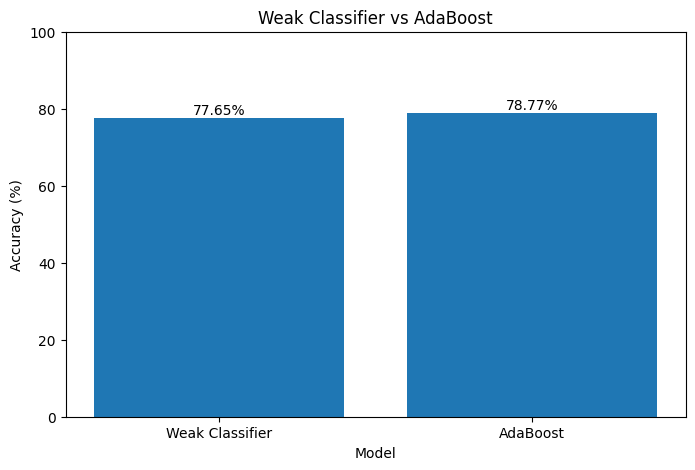


AdaBoost Feature Importance:
  Feature  Importance
2     Age    0.361671
1     Sex    0.211910
3   SibSp    0.188235
0  Pclass    0.128588
5    Fare    0.109597
4   Parch    0.000000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported")

# Load Titanic dataset
dataset = pd.read_csv("/content/titanic.csv")

print("Dataset Loaded")

print("\nFirst 5 rows:")
print(dataset.head())

print("\nDataset Shape:")
print(dataset.shape)

# Select required columns
dataset = dataset[
    ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
]

# Convert Sex into numerical values
dataset['Sex'] = dataset['Sex'].map({
    'male': 0,
    'female': 1
})

# Fill missing Age values
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())

print("\nData after preprocessing:")
print(dataset.head())

# Separate features and target
X = dataset.drop('Survived', axis=1)
y = dataset['Survived']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

# --------------------------------------------------
# INDIVIDUAL WEAK CLASSIFIER
# --------------------------------------------------

weak_classifier = DecisionTreeClassifier(
    max_depth=1,
    random_state=0
)

# Train weak classifier
weak_classifier.fit(X_train, y_train)

# Predict using weak classifier
weak_pred = weak_classifier.predict(X_test)

# Calculate weak classifier accuracy
weak_accuracy = accuracy_score(
    y_test,
    weak_pred
)

print("\n--------------------------------")
print("INDIVIDUAL WEAK CLASSIFIER")
print("--------------------------------")

print("Weak Classifier:")
print(weak_classifier)

print("\nWeak Classifier Accuracy:")
print(weak_accuracy * 100, "%")

print("\nWeak Classifier Confusion Matrix:")
print(confusion_matrix(y_test, weak_pred))

print("\nWeak Classifier Report:")
print(
    classification_report(
        y_test,
        weak_pred
    )
)

# --------------------------------------------------
# ADABOOST ENSEMBLE
# --------------------------------------------------

adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=0
    ),
    n_estimators=50,
    learning_rate=1.0,
    random_state=0
)

# Train AdaBoost
adaboost_model.fit(X_train, y_train)

print("\n--------------------------------")
print("ADABOOST ENSEMBLE MODEL")
print("--------------------------------")

print("AdaBoost Model:")
print(adaboost_model)

# Predict using AdaBoost
ada_pred = adaboost_model.predict(X_test)

print("\nAdaBoost Predicted Results:")
print(ada_pred)

print("\nActual Results:")
print(y_test.values)

# Calculate AdaBoost accuracy
ada_accuracy = accuracy_score(
    y_test,
    ada_pred
)

print("\nAdaBoost Accuracy:")
print(ada_accuracy * 100, "%")

# Confusion Matrix
ada_cm = confusion_matrix(
    y_test,
    ada_pred
)

print("\nAdaBoost Confusion Matrix:")
print(ada_cm)

# Classification Report
print("\nAdaBoost Classification Report:")
print(
    classification_report(
        y_test,
        ada_pred
    )
)

# --------------------------------------------------
# COMPARISON
# --------------------------------------------------

print("\n--------------------------------")
print("MODEL COMPARISON")
print("--------------------------------")

print(
    "Individual Weak Classifier Accuracy:",
    weak_accuracy * 100,
    "%"
)

print(
    "AdaBoost Accuracy:",
    ada_accuracy * 100,
    "%"
)

improvement = (
    ada_accuracy - weak_accuracy
) * 100

print(
    "Improvement using AdaBoost:",
    improvement,
    "percentage points"
)

# --------------------------------------------------
# ACCURACY COMPARISON GRAPH
# --------------------------------------------------

models = [
    "Weak Classifier",
    "AdaBoost"
]

accuracies = [
    weak_accuracy * 100,
    ada_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    accuracies
)

plt.xlabel("Model")

plt.ylabel("Accuracy (%)")

plt.title("Weak Classifier vs AdaBoost")

plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

# --------------------------------------------------
# ADABOOST FEATURE IMPORTANCE
# --------------------------------------------------

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': adaboost_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nAdaBoost Feature Importance:")
print(feature_importance)